<a href="https://colab.research.google.com/github/a-micable/vehicle_anomaly-Detection/blob/main/amic_thegreat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving vehicle_sensor_data.csv to vehicle_sensor_data.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the data
df = pd.read_csv('vehicle_sensor_data.csv')

# Select features and target
X = df[['engine_temperature', 'speed']]
y = df['anomaly_type']

# Encode target labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'normal': np.int64(0), 'speed_anomaly': np.int64(1), 'temperature_anomaly': np.int64(2)}


## EDA

In [ ]:
import matplotlib.pyplot as plt

print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
                 timestamp  engine_temperature       speed  \
0  2023-01-01 00:00:00.000           74.440599   66.378044   
1  2023-01-01 00:52:33.600           87.896064  147.674347   
2  2023-01-01 01:45:07.200           97.095609   49.496604   
3  2023-01-01 02:37:40.800           81.209811  120.867198   
4  2023-01-01 03:30:14.400           84.082225   29.522480   

          anomaly_type                                     recommendation  \
0               normal                    All systems operating normally.   
1        speed_anomaly  Critical: Speed is dangerously high. Reduce sp...   
2  temperature_anomaly  Warning: Engine temperature is elevated. Consi...   
3        speed_anomaly  Warning: Speed is above normal range. Consider...   
4               normal                    All systems operating normally.   

   confidence_score  hour  day_of_week  month  ambient_temperature  season  \
0          0.950000     0            6      1            20.000000     

In [ ]:
print("\nDataset Description:")
print(df.describe())

print("\nValue counts for target variable:")
print(df['anomaly_type'].value_counts())


Dataset Description:
       engine_temperature         speed  confidence_score          hour  \
count        10000.000000  10000.000000      10000.000000  10000.000000   
mean            81.978115     68.209713          0.936019     11.496000   
std              7.739883     31.058666          0.043251      6.922628   
min             60.387999      0.000000          0.493540      0.000000   
25%             77.051534     48.115367          0.950000      5.750000   
50%             80.708872     62.965397          0.950000     11.500000   
75%             84.872481     79.451869          0.950000     17.250000   
max            115.491497    175.058714          0.950000     23.000000   

       day_of_week         month  ambient_temperature        season  
count  10000.00000  10000.000000         10000.000000  10000.000000  
mean       3.00840      6.525600            20.000000      2.504100  
std        2.00343      3.448062             7.071421      1.114409  
min        0.00000    

In [ ]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
timestamp              0
engine_temperature     0
speed                  0
anomaly_type           0
recommendation         0
confidence_score       0
hour                   0
day_of_week            0
month                  0
ambient_temperature    0
season                 0
traffic_condition      0
weather_condition      0
road_type              0
dtype: int64


In [ ]:
# Correlation matrix (for numerical features)
print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))


Correlation Matrix:
                     engine_temperature     speed  confidence_score      hour  \
engine_temperature             1.000000 -0.062869         -0.236503 -0.008898   
speed                         -0.062869  1.000000         -0.281244 -0.002915   
confidence_score              -0.236503 -0.281244          1.000000  0.005654   
hour                          -0.008898 -0.002915          0.005654  1.000000   
day_of_week                    0.009231 -0.008531         -0.005071  0.000031   
month                          0.010924  0.013124         -0.007897  0.001169   
ambient_temperature            0.003716 -0.009509          0.000900 -0.775757   
season                         0.018434 -0.007161          0.006503 -0.000795   

                     day_of_week     month  ambient_temperature    season  
engine_temperature      0.009231  0.010924             0.003716  0.018434  
speed                  -0.008531  0.013124            -0.009509 -0.007161  
confidence_score     

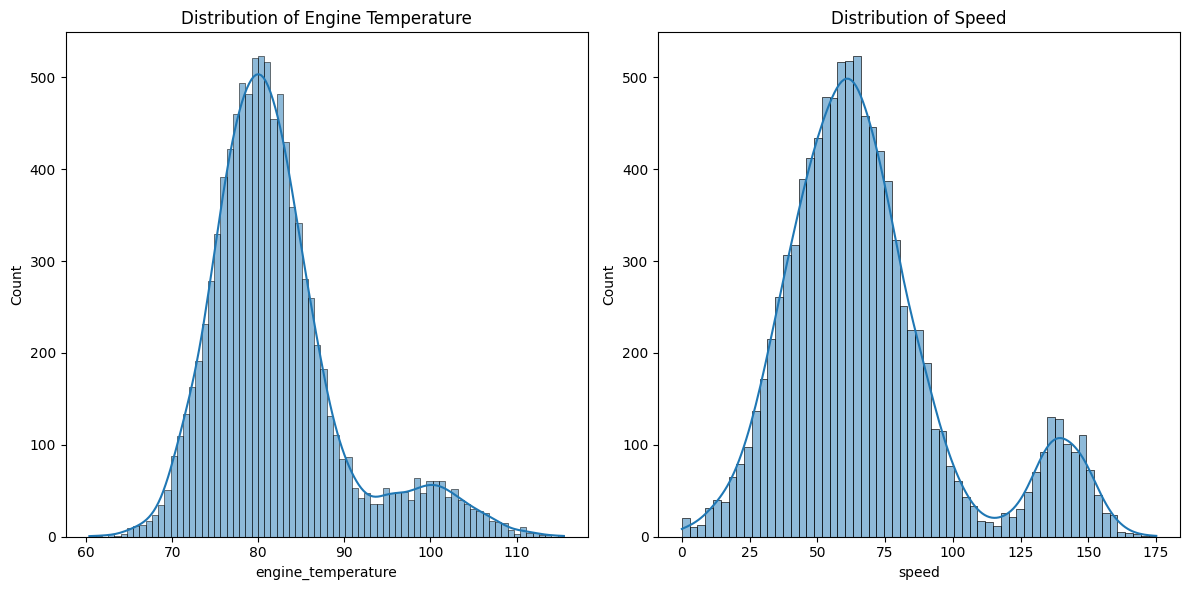

In [ ]:

# Visualize distributions
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['engine_temperature'], kde=True)
plt.title('Distribution of Engine Temperature')

plt.subplot(1, 2, 2)
sns.histplot(df['speed'], kde=True)
plt.title('Distribution of Speed')
plt.tight_layout()
plt.show()

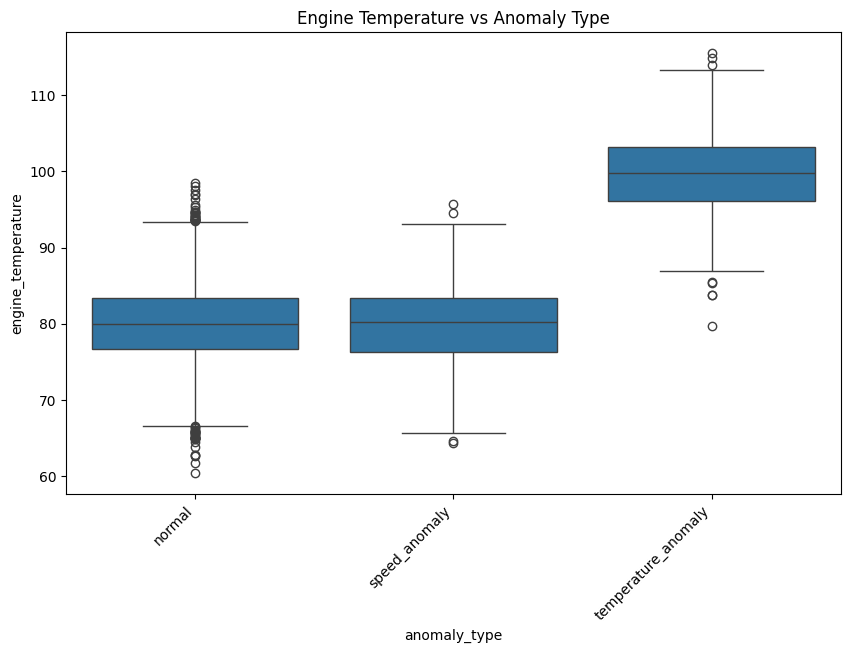

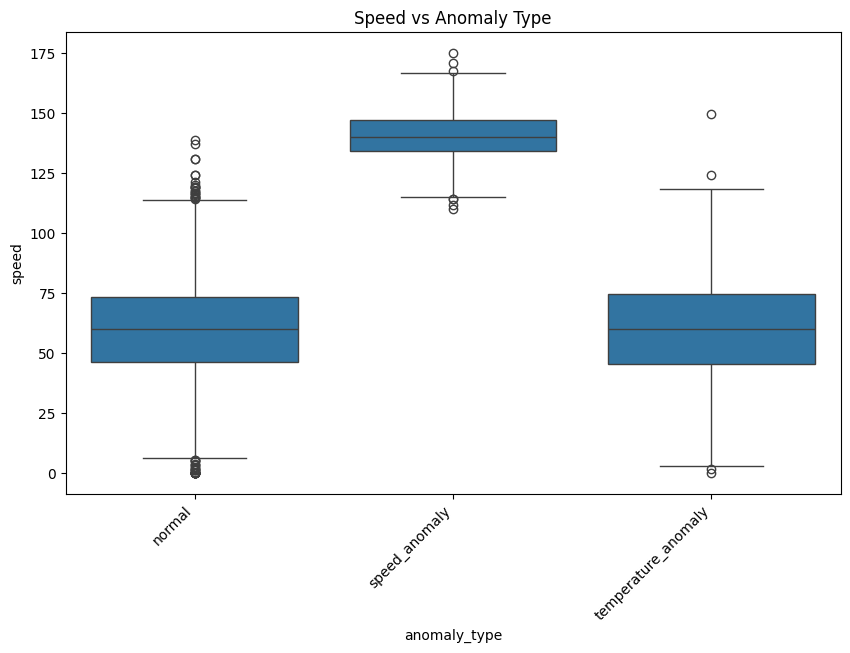

In [ ]:
# Visualize relationships between features and target
plt.figure(figsize=(10, 6))
sns.boxplot(x='anomaly_type', y='engine_temperature', data=df)
plt.title('Engine Temperature vs Anomaly Type')
plt.xticks(rotation=45, ha='right')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='anomaly_type', y='speed', data=df)
plt.title('Speed vs Anomaly Type')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Classification Report:
                      precision    recall  f1-score   support

             normal       0.99      0.99      0.99      1599
      speed_anomaly       0.99      1.00      0.99       204
temperature_anomaly       0.94      0.92      0.93       197

           accuracy                           0.99      2000
          macro avg       0.97      0.97      0.97      2000
       weighted avg       0.99      0.99      0.99      2000



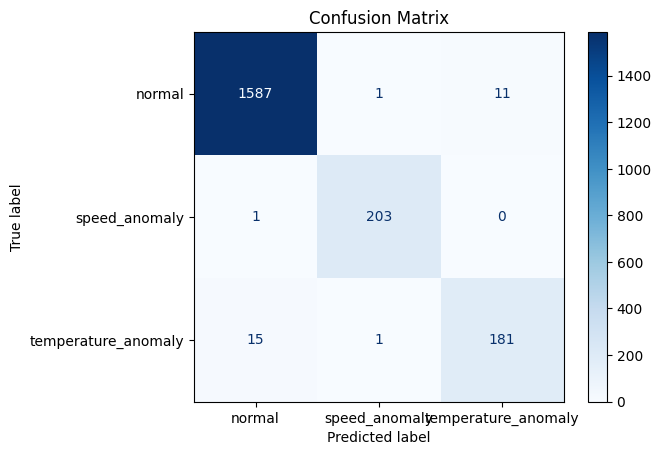

In [ ]:
y_pred = rf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
cv_scores = cross_val_score(rf, X, y_encoded, cv=5, scoring='f1_weighted')
print("Cross-validated F1 scores:", cv_scores)
print("Mean F1 score:", np.mean(cv_scores))

Cross-validated F1 scores: [0.98339812 0.98803427 0.98435676 0.98746558 0.9859848 ]
Mean F1 score: 0.9858479078056398


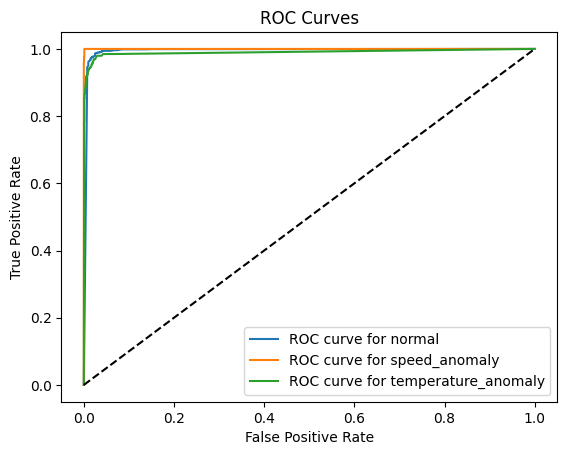

In [ ]:
from sklearn.preprocessing import label_binarize

# Binarize the output for ROC curve
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = rf.predict_proba(X_test)

for i, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f"ROC curve for {class_name}")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [ ]:
import joblib
joblib.dump(rf, 'engine_health_rf_model.pkl')
joblib.dump(le, 'engine_health_label_encoder.pkl')
print("Model and label encoder saved!")

Model and label encoder saved!


In [ ]:
# Load model and encoder
rf_loaded = joblib.load('engine_health_rf_model.pkl')
le_loaded = joblib.load('engine_health_label_encoder.pkl')

# Example prediction
sample = np.array([[85, 130]])  # [engine_temperature, speed]
pred = rf_loaded.predict(sample)
print("Predicted class:", le_loaded.inverse_transform(pred))

Predicted class: ['speed_anomaly']


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# all anomaly types
print("All anomaly types:", le_loaded.classes_)

All anomaly types: ['normal' 'speed_anomaly' 'temperature_anomaly']


In [ ]:
import numpy as np
import pandas as pd

def predict_anomaly(temp, speed, model):
  input = np.array([[temp, speed]])
  input_df = pd.DataFrame(input, columns=['engine_temperature', 'speed'])
  pred = model.predict(input_df)
  # Inverse transform the prediction to get the original class name
  result = le_loaded.inverse_transform(pred)[0] # Get the first element from the array
  # user friendly message mapping
  anomaly_mapping = {
      'normal': 'The vehicle is operating normally.',
      'speed_anomaly': 'Speed anomaly detected. The vehicle speed is outside the expected range.',
      'temperature_anomaly': 'Temperature anomaly detected. The engine temperature is outside the expected range.',
  }
  return anomaly_mapping.get(result, "Unknown anomaly type detected.") # Use .get() to handle potential unseen classes

In [ ]:
from IPython.display import display
import ipywidgets as widgets

# Loading the model (let's assume this code block will run indepedently in the prod)
try:
    rf_loaded = joblib.load('engine_health_rf_model.pkl')
    le_loaded = joblib.load('engine_health_label_encoder.pkl')
except FileNotFoundError:
    print("Model or label encoder not found. Please ensure 'engine_health_rf_model.pkl' and 'engine_health_label_encoder.pkl' are in the correct directory.")
    rf_loaded = None
    le_loaded = None

if rf_loaded is not None and le_loaded is not None:
    # Create input widgets
    temp_input = widgets.FloatText(
        value=80.0,
        description='Engine Temperature (C):',
        disabled=False,
        description_layout=widgets.Layout(width='70%'),
        layout=widgets.Layout(width='50%')
    )

    speed_input = widgets.FloatText(
        value=100.0,
        description='Speed (kph):',
        disabled=False,
        layout=widgets.Layout(width='50%'),
        description_layout=widgets.Layout(width='initial')
    )

    predict_button = widgets.Button(
        description='Predict Anomaly',
        disabled=False,
        button_style='info',
        tooltip='Click to predict anomaly',
        icon='check'
    )

    output_area = widgets.Output()

    # Function to handle button click
    def on_predict_button_clicked(b):
        with output_area:
            output_area.clear_output()
            temp = temp_input.value
            speed = speed_input.value

            # Input validation
            if not isinstance(temp, (int, float)) or not isinstance(speed, (int, float)):
                 print("Invalid input. Please enter numeric values for temperature and speed.")
                 return
            if temp < 0 or speed < 0:
                 print("Invalid input. Temperature and speed cannot be negative.")
                 return
            # Add any other relevant validation based on expected ranges from training data

            try:
                prediction_message = predict_anomaly(temp, speed, rf_loaded)
                print("Prediction:", prediction_message)
            except Exception as e:
                print(f"An error occurred during prediction: {e}")

    predict_button.on_click(on_predict_button_clicked)

    input_widgets = widgets.VBox([temp_input, speed_input, predict_button], layout=widgets.Layout(align_items='center', width='40%'))
    gui = widgets.VBox([widgets.HTML("<h2>Vehicle Anomaly Prediction</h2>"), input_widgets, output_area], layout=widgets.Layout(align_items='center')) # Add a title

    display(gui)